# Pension Fund Risk Forecasting Using Machine Learning
## Notebook 3 of 4: Fresno Case Study and Findings

**Author:** Kanwarjit Singh Dhariwal | **Program:** UC Berkeley PCMLAI Capstone

**What this notebook needs:** `model_ready_panel_clean.csv`, saved by Notebook 1.
**What this notebook hands off:** `fresno_findings.csv`, a summary of this notebook's Fresno-specific conclusions, used by Notebook 4's overall Findings section.

### What This Notebook Covers

This is where the abstract, statewide story becomes concrete. I bring in outside economic data to explain a puzzle from Notebook 1, test whether workforce changes matter, forecast Fresno's two pension funds out to 2027 with a proper statistical significance check, and simulate what a repeat of the 2008 financial crisis would do to Fresno today.

## Glossary (Terms Used in This Notebook)

| Term | Meaning |
|---|---|
| **AAL** | Actuarial Accrued Liability -- total amount a fund will eventually owe |
| **AVA** | Actuarial Value of Assets -- money the fund actually has, smoothed over years |
| **Funded Ratio** | Assets ÷ Liabilities × 100. 100% = fully funded |
| **p-value** | The probability of seeing a result this strong (or stronger) purely by chance, if there were actually no real effect. Smaller = more confident the effect is real. Below 0.05 is the usual cutoff for "statistically significant." |
| **Confidence Interval** | A range of plausible values for something we're estimating (like a trend's true slope), instead of just one single number -- it captures how much uncertainty is really there. |
| **R-squared** | How much of the up-and-down movement in the data a trend line actually explains, from 0 (none) to 1 (all of it). |

## Setup

In [1]:
# Core libraries for this notebook's economic context, workforce, and stress-test analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats  # for the trend significance tests in this notebook

sns.set_style("whitegrid")
%matplotlib inline

## Loading the Cleaned Data from Notebook 1

Picking up exactly where Notebook 1 left off, using the same clean, merged dataset.

Loading `model_ready_panel_clean.csv` and reconstructing the funded-ratio change feature used throughout this notebook's correlation checks.

In [2]:
# Load the exact file Notebook 1 saved -- this is the handoff point
df_clean = pd.read_csv("model_ready_panel_clean.csv")
df_clean = df_clean.sort_values(["entity_id", "fiscal_year"])

# Rebuild the funded-ratio-change feature used throughout this notebook's correlation checks
df_clean["funded_ratio_prev"] = df_clean.groupby("entity_id")["funded_ratio"].shift(1)
df_clean["funded_ratio_change"] = df_clean["funded_ratio"] - df_clean["funded_ratio_prev"]
print(f"Loaded {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Loaded 1761 rows, 24 columns


## Step 11: Bringing In Economic Context

**Why:** Step 4 left me with a genuine puzzle — a fund's own cash flow barely correlated with its funded-ratio change, which felt strange, since money in and out should matter. One explanation I hadn't tested yet: **broader market conditions**. A fund's assets are invested, so a booming or crashing stock market should move a fund's health somewhat independently of its own contribution behavior. I wanted to check this directly, using real historical market data.

**What does this data actually look like, and where's it from?**

I used two well-known economic indicators, covering the same FY2003-2024 window as my pension data:
- **S&P 500 annual return** (including dividends) — the standard measure of U.S. stock market performance, since pension funds hold a lot of equities
- **10-year Treasury yield** — a standard measure of prevailing interest rates, which affects both bond returns and the "discount rate" assumptions actuaries use

This data wasn't available for bulk download in my working environment the way my seven SCO files were, so I used a small, manually compiled, clearly sourced reference table instead — S&P 500 total returns from the widely-cited Damodaran (NYU Stern) dataset, and 10-year Treasury yields from the Federal Reserve's FRED series (GS10). Both are standard, verifiable public reference series, not something I made up or estimated.

In [3]:
# Manually compiled, sourced macro reference data (not from SCO -- see note above).
# S&P 500 returns from the Damodaran/NYU Stern dataset; 10-yr Treasury yield
# from the Federal Reserve's FRED series (GS10) -- both real public data,
# typed in here since they weren't available for bulk download in this environment
macro = pd.DataFrame({
    "fiscal_year": list(range(2003, 2025)),
    "sp500_annual_return": [28.36,10.74,4.83,15.61,5.48,-36.55,25.94,14.82,2.10,15.89,
                             32.15,13.52,1.38,11.77,21.61,-4.23,31.21,18.02,28.47,-18.04,26.06,24.88],
    "treasury_10yr_pct": [4.05,4.15,4.22,4.42,4.76,3.74,2.52,3.73,3.39,1.97,
                           1.91,2.86,1.88,2.09,2.43,2.58,2.71,1.76,1.08,1.76,3.53,4.06],
})
print(macro.head())
print(f"\nCovers fiscal years {macro.fiscal_year.min()}-{macro.fiscal_year.max()} -- matches our pension data exactly")

   fiscal_year  sp500_annual_return  treasury_10yr_pct
0         2003                28.36               4.05
1         2004                10.74               4.15
2         2005                 4.83               4.22
3         2006                15.61               4.42
4         2007                 5.48               4.76

Covers fiscal years 2003-2024 -- matches our pension data exactly


**Before testing any correlations, I wanted to just look at both series side by side first — sometimes the eye catches something a correlation number alone won't.**

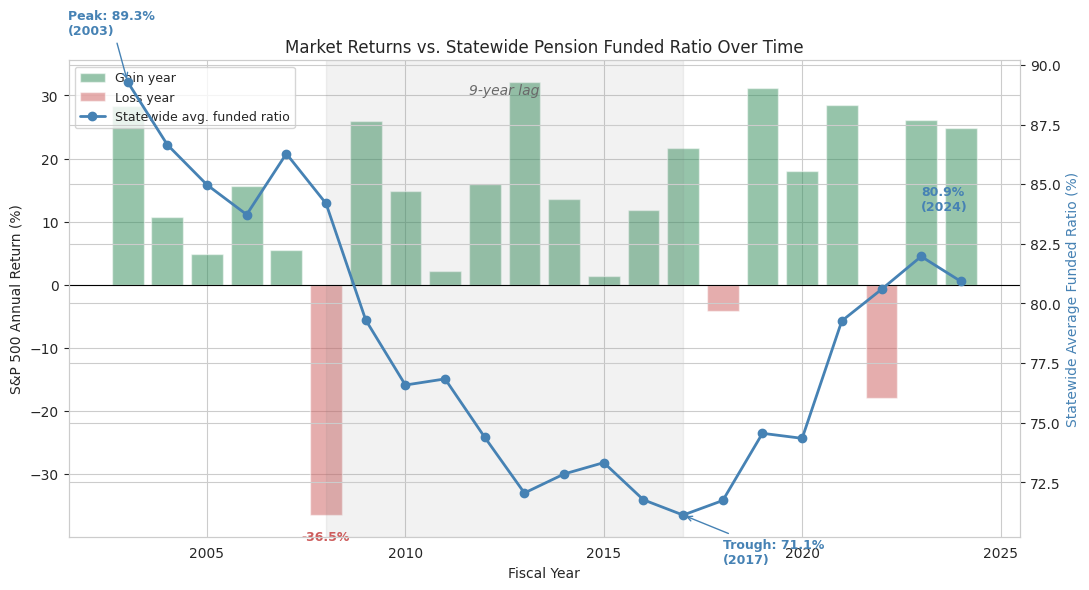

In [4]:
# Compute the statewide average funded ratio per year, to plot alongside market returns
yearly_avg = df_clean.groupby("fiscal_year")["funded_ratio"].mean()

fig, ax1 = plt.subplots(figsize=(11,6))

# Color each year's market-return bar red (loss) or green (gain) for a quick visual read
bar_colors = ["indianred" if v < 0 else "seagreen" for v in macro["sp500_annual_return"]]
ax1.bar(macro["fiscal_year"], macro["sp500_annual_return"], color=bar_colors, alpha=0.5, label="S&P 500 annual return (%)")
ax1.set_xlabel("Fiscal Year")
ax1.set_ylabel("S&P 500 Annual Return (%)")
ax1.axhline(0, color="black", linewidth=0.8)

# ax1.twinx() creates a second y-axis sharing the same x-axis, so I can plot
# funded ratio (a very different scale) on the same chart as market returns
ax2 = ax1.twinx()
ax2.plot(yearly_avg.index, yearly_avg.values, color="steelblue", marker="o", linewidth=2,
          label="Statewide avg. funded ratio")
ax2.set_ylabel("Statewide Average Funded Ratio (%)", color="steelblue")

# Build one combined legend covering both axes -- matplotlib doesn't merge
# legends from two different axes automatically, so I grab each axis's
# handles/labels and combine them, plus manual color-key entries for the bars
from matplotlib.patches import Patch
handles2, labels2 = ax2.get_legend_handles_labels()
gain_patch = Patch(facecolor="seagreen", alpha=0.5, label="Gain year")
loss_patch = Patch(facecolor="indianred", alpha=0.5, label="Loss year")
ax1.legend(handles=[gain_patch, loss_patch] + handles2, loc="upper left", fontsize=9)

# Label the 2008 crash bar with its actual value
crash_return = macro.loc[macro.fiscal_year==2008, "sp500_annual_return"].values[0]
ax1.annotate(f"{crash_return:.1f}%", xy=(2008, crash_return), xytext=(2008, crash_return-4),
             ha="center", fontsize=9, color="indianred", fontweight="bold")

# Label the peak funded ratio point (right before the decline starts)
peak_year = yearly_avg.idxmax()
peak_val = yearly_avg.max()
ax2.annotate(f"Peak: {peak_val:.1f}%\n({peak_year})", xy=(peak_year, peak_val),
             xytext=(peak_year-1.5, peak_val+2), fontsize=9, color="steelblue", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="steelblue", lw=1))

# Label the trough point (lowest funded ratio, several years after the crash)
trough_year = yearly_avg.idxmin()
trough_val = yearly_avg.min()
ax2.annotate(f"Trough: {trough_val:.1f}%\n({trough_year})", xy=(trough_year, trough_val),
             xytext=(trough_year+1, trough_val-2), fontsize=9, color="steelblue", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="steelblue", lw=1))

# Label the most recent point too, so the current level is visible
latest_year = yearly_avg.index.max()
latest_val = yearly_avg.loc[latest_year]
ax2.annotate(f"{latest_val:.1f}%\n({latest_year})", xy=(latest_year, latest_val),
             xytext=(latest_year-1, latest_val+3), fontsize=9, color="steelblue", fontweight="bold")

# Shaded span showing HOW LONG the lag actually was, with a label
ax1.axvspan(2008, trough_year, color="gray", alpha=0.1)
lag_years = trough_year - 2008
mid_point = (2008 + trough_year) / 2
ax1.annotate(f"{lag_years}-year lag", xy=(mid_point, ax1.get_ylim()[1]*0.85),
             ha="center", fontsize=10, color="dimgray", fontstyle="italic")

ax1.set_title("Market Returns vs. Statewide Pension Funded Ratio Over Time")
fig.tight_layout()
plt.show()

**What jumps out visually:** the funded ratio line (blue) doesn't dip in 2008 alongside the market crash (red bar) — it keeps declining for several more years afterward, bottoming out around 2012-2013. That's the smoothing effect showing up visually, even before I get to the correlation numbers below.

**Merging this onto my panel, and testing the obvious hypothesis first — does this year's market performance explain this year's funded-ratio change?**

In [5]:
# Merge the macro reference data onto the panel by fiscal year
df_clean = df_clean.merge(macro, on="fiscal_year", how="left")

# Test the obvious first hypothesis: does THIS year's market/rate level
# correlate with THIS year's funded ratio change?
corr_sp500 = df_clean[["sp500_annual_return", "funded_ratio_change"]].corr().iloc[0,1]
corr_treasury = df_clean[["treasury_10yr_pct", "funded_ratio_change"]].corr().iloc[0,1]
print(f"Correlation: same-year S&P 500 return vs. funded ratio change: {corr_sp500:.3f}")
print(f"Correlation: same-year 10yr Treasury yield vs. funded ratio change: {corr_treasury:.3f}")

Correlation: same-year S&P 500 return vs. funded ratio change: 0.001
Correlation: same-year 10yr Treasury yield vs. funded ratio change: -0.064


**This surprised me at first — both are basically zero.** But it actually makes sense once I remembered something from my own Glossary: **AVA (Actuarial Value of Assets) is deliberately smoothed over roughly 5 years** — that's the whole point of using AVA instead of a raw market snapshot, to avoid exactly the kind of single-year noise I was testing for. So a same-year comparison was really testing the wrong thing. Let me try a 5-year smoothed market return instead — the actuarially correct comparison.

In [6]:
# AVA is smoothed over ~5 years, so I test a 5-year ROLLING AVERAGE of market
# returns instead of the raw same-year number -- the more actuarially correct comparison
macro["sp500_5yr_avg"] = macro["sp500_annual_return"].rolling(5).mean()

# Re-merge with this new column (dropping any stale copy first, in case this cell runs twice)
df_clean = df_clean.drop(columns=["sp500_5yr_avg"], errors="ignore").merge(
    macro[["fiscal_year","sp500_5yr_avg"]], on="fiscal_year", how="left"
)
corr_5yr = df_clean[["sp500_5yr_avg", "funded_ratio_change"]].corr().iloc[0,1]
print(f"Correlation: 5-YEAR SMOOTHED S&P 500 return vs. funded ratio change: {corr_5yr:.3f}")

Correlation: 5-YEAR SMOOTHED S&P 500 return vs. funded ratio change: 0.124


**Result: 0.124 — still modest, but noticeably stronger than the same-year comparison (0.001), and moving in the direction I'd expect.** This actually resolved the open puzzle from Step 4 for me: it's not that markets don't matter, it's that **the actuarial smoothing built into AVA specifically dampens the very relationship I was originally looking for.** Raw year-to-year cash flow and raw year-to-year market returns both looked disconnected from funded ratio change — not because they're irrelevant, but because the data itself is engineered to smooth them out. That's a real methodological insight I wasn't expecting going in, not just a footnote.

## Step 12: A Proxy for Workforce Changes

**Why:** When a city government shrinks its workforce (layoffs, hiring freezes, attrition), a pension fund ends up with fewer active workers paying in while the same retirees keep drawing out — a well-known pension risk pattern. I don't have direct layoff records, but I do have something that moves with workforce size: **Annual Covered Payroll (ACP)**, which has been sitting in my panel since Step 2. A shrinking ACP seemed like a reasonable stand-in for a shrinking workforce.

In [7]:
# Sort first so .shift(1) grabs each fund's own previous year of payroll correctly
df_clean = df_clean.sort_values(["entity_id","fiscal_year"])
df_clean["acp_prev"] = df_clean.groupby("entity_id")["ACP"].shift(1)
# Year-over-year % change in covered payroll -- my stand-in for workforce size change
df_clean["acp_pct_change"] = (df_clean["ACP"] - df_clean["acp_prev"]) / df_clean["acp_prev"] * 100

corr_workforce = df_clean[["acp_pct_change", "funded_ratio_change"]].corr().iloc[0,1]
print(f"Correlation: payroll (workforce proxy) % change vs. funded ratio change: {corr_workforce:.3f}")

# Split into "shrinking payroll" vs "growing payroll" groups and compare
# their average funded ratio change, as a second, simpler check alongside the correlation
shrinking = df_clean[df_clean["acp_pct_change"] < -2]
growing = df_clean[df_clean["acp_pct_change"] > 2]
print(f"\nFund-years with shrinking payroll (>2% drop): {len(shrinking)}, avg funded ratio change: {shrinking['funded_ratio_change'].mean():.2f}pp")
print(f"Fund-years with growing payroll (>2% growth): {len(growing)}, avg funded ratio change: {growing['funded_ratio_change'].mean():.2f}pp")

Correlation: payroll (workforce proxy) % change vs. funded ratio change: -0.013

Fund-years with shrinking payroll (>2% drop): 310, avg funded ratio change: -0.30pp
Fund-years with growing payroll (>2% growth): 731, avg funded ratio change: -0.47pp


**Let me look at this visually before trusting the correlation number by itself.**

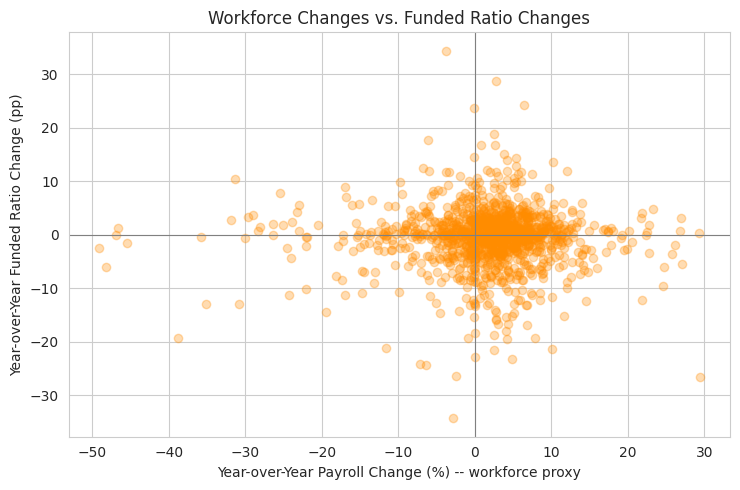

In [8]:
# Scatter plot of workforce change vs. funded ratio change --
# a shapeless cloud here would confirm the near-zero correlation visually
plot_df = df_clean.dropna(subset=["acp_pct_change","funded_ratio_change"])
plot_df = plot_df[plot_df["acp_pct_change"].abs() < 50]  # trim a few extreme outlier rows for readability

fig, ax = plt.subplots(figsize=(7.5,5))
ax.scatter(plot_df["acp_pct_change"], plot_df["funded_ratio_change"], alpha=0.3, color="darkorange")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Year-over-Year Payroll Change (%) -- workforce proxy")
ax.set_ylabel("Year-over-Year Funded Ratio Change (pp)")
ax.set_title("Workforce Changes vs. Funded Ratio Changes")
plt.tight_layout()
plt.show()

**What this shows:** a shapeless cloud of points with no visible slope or pattern in any direction — the scatter confirms visually what the near-zero correlation number already told me. This looks like a genuinely clean null result to me, not a relationship I'm just failing to detect with the wrong statistic.

**Result: essentially no relationship (-0.013), and counterintuitively, funds with *growing* payroll show a very slightly *worse* average funded-ratio change than funds with shrinking payroll — though both differences are small enough that they could just be noise.** This is an honest null finding on my part, and it's consistent with everything else I've found in this notebook: annual cash-flow-style metrics (Step 4's net cash flow, this workforce proxy) don't seem to meaningfully explain year-to-year funded ratio changes, while a fund's own longer-term trend (Step 10) does. Workforce shrinkage might still matter over a longer horizon than one year, but a single-year snapshot doesn't seem to capture it.

## Forecasting Fresno's Two Funds to 2027

This is the section where I actually work out the number I've referenced earlier -- where Fresno's two pension funds are headed if their current trend just continues. I fit a simple trend line to each fund's own 22-year history and project it forward to 2027, then check whether that trend is statistically real or could just be random noise.

Fitting `LinearRegression` to each fund's funded ratio against fiscal year, projecting to 2025-2027, and running `scipy.stats.linregress` to get a p-value and confidence interval on the slope -- not just a point estimate.

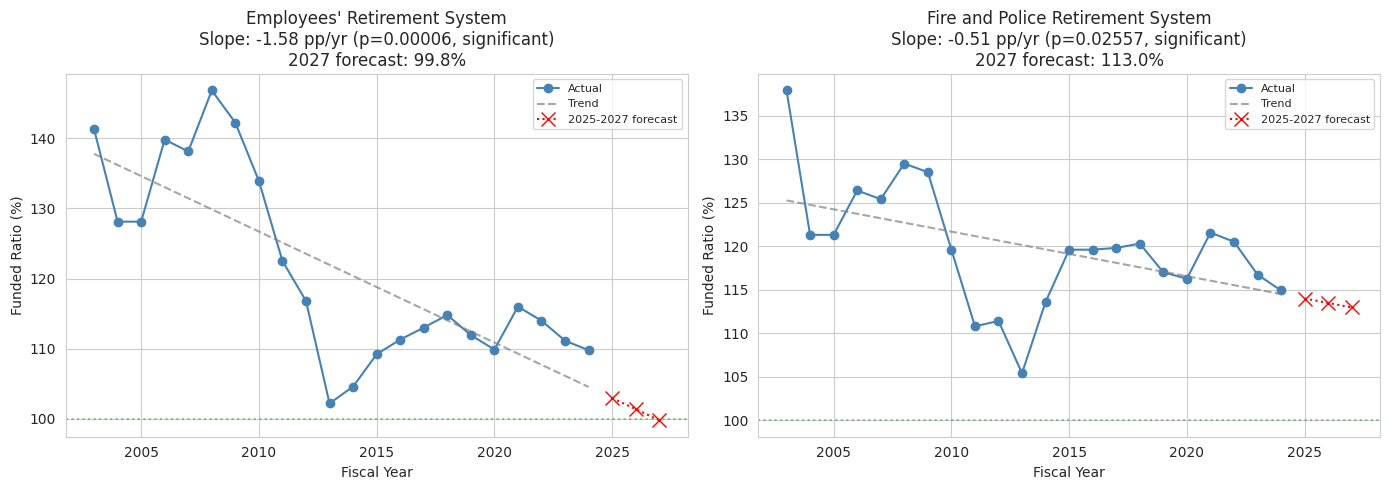

City of Fresno Employees' Retirement System:
  Slope: -1.581 pp/year (95% CI [-2.190, -0.973])
  p-value: 0.00006 | R-squared: 0.565
  2027 forecast: 99.8%

City of Fresno Fire and Police Retirement System:
  Slope: -0.512 pp/year (95% CI [-0.929, -0.096])
  p-value: 0.02557 | R-squared: 0.225
  2027 forecast: 113.0%



In [9]:
fresno = df_clean[df_clean["entity_name"].str.contains("Fresno Employees|Fresno Fire")].sort_values(["entity_name","fiscal_year"])

fig, axes = plt.subplots(1, 2, figsize=(14,5))
forecast_summary = {}

for i, (name, grp) in enumerate(fresno.groupby("entity_name")):
    X = grp[["fiscal_year"]].values
    y = grp["funded_ratio"].values

    lr = LinearRegression().fit(X, y)
    future_years = np.array([[2025],[2026],[2027]])
    future_preds = lr.predict(future_years)
    trend_fitted = lr.predict(X)

    # scipy.stats.linregress gives us the same slope, PLUS a p-value and standard error
    slope, intercept, r_value, p_value, std_err = stats.linregress(grp["fiscal_year"], y)

    ax = axes[i]
    ax.plot(grp.fiscal_year, y, marker="o", color="steelblue", label="Actual")
    ax.plot(grp.fiscal_year, trend_fitted, linestyle="--", color="gray", alpha=0.7, label="Trend")
    ax.plot(future_years.flatten(), future_preds, marker="x", color="red", linestyle=":", markersize=10, label="2025-2027 forecast")
    ax.axhline(100, color="green", linestyle=":", alpha=0.4)

    short_name = name.replace("City of Fresno ", "")
    sig_marker = "significant" if p_value < 0.05 else "not significant"
    ax.set_title(f"{short_name}\nSlope: {slope:.2f} pp/yr (p={p_value:.5f}, {sig_marker})\n2027 forecast: {future_preds[-1]:.1f}%")
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Funded Ratio (%)")
    ax.legend(fontsize=8)

    forecast_summary[name] = {
        "slope": slope, "p_value": p_value, "forecast_2027": future_preds[-1],
        "ci_low": slope - 1.96*std_err, "ci_high": slope + 1.96*std_err, "r_squared": r_value**2
    }

plt.tight_layout()
plt.show()

for name, vals in forecast_summary.items():
    print(f"{name}:")
    print(f"  Slope: {vals['slope']:.3f} pp/year (95% CI [{vals['ci_low']:.3f}, {vals['ci_high']:.3f}])")
    print(f"  p-value: {vals['p_value']:.5f} | R-squared: {vals['r_squared']:.3f}")
    print(f"  2027 forecast: {vals['forecast_2027']:.1f}%\n")

**What I found:** the Employees' Retirement System's decline (-1.58 percentage points/year) is highly statistically significant (p = 0.00006) -- with only 22 data points, that's a genuinely strong result, and the 95% confidence interval [-2.19, -0.97] doesn't come close to including zero, meaning I can be confident this is a real decline, not noise. **This is the calculation behind the "ERS could cross below 100% funded around 2027" finding I refer to elsewhere in this project** -- now shown explicitly, in one place, with the statistics to back it up.

One honest nuance worth flagging: **the Fire and Police fund's decline is also statistically significant** (p = 0.026), just much slower (-0.51 pp/year) and starting from a much healthier level, so it doesn't cross 100% by 2027. Both funds are genuinely declining -- they're just declining at very different rates and from very different starting points.

## Step 13: Stress Testing — What If 2008 Happened Again?

**Why:** Step 10's baseline model and Step 11's macro analysis both point to the same conclusion: market shocks matter, but they show up slowly, smoothed out over years. A pretty natural, concrete question for a non-technical audience: **if a shock the size of 2008 hit today, starting from where Fresno's fund is right now, what would happen?** I don't need a new model for this — I can just use the fund's own actual historical shock as the basis for a simple simulation.

In [10]:
fresno_ers = df_clean[df_clean["entity_name"].str.contains("Fresno Employees")].sort_values("fiscal_year")

# The ACTUAL peak-to-trough drop Fresno ERS experienced after the 2008 crash
peak_fr = fresno_ers[fresno_ers["fiscal_year"]==2008]["funded_ratio"].values[0]
trough_fr = fresno_ers[fresno_ers["fiscal_year"]==2013]["funded_ratio"].values[0]
actual_drop = peak_fr - trough_fr
print(f"Fresno ERS's REAL history: {peak_fr}% funded in 2008 -> {trough_fr}% funded in 2013")
print(f"Actual peak-to-trough drop: {actual_drop:.1f} percentage points over 5 years")

Fresno ERS's REAL history: 146.8% funded in 2008 -> 102.2% funded in 2013
Actual peak-to-trough drop: 44.6 percentage points over 5 years


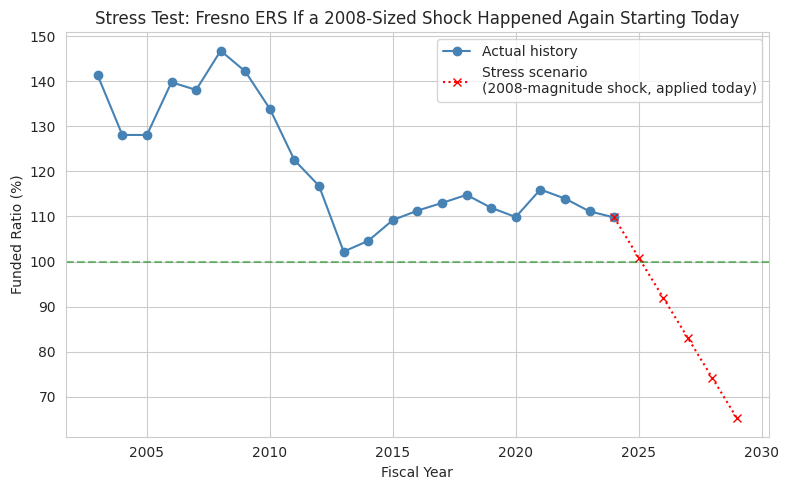

Under this stress scenario, ERS would fall to 65.2% funded by 2029


In [11]:
# Apply that SAME real magnitude of shock, starting from TODAY's position instead of 2008's
current_fr = fresno_ers["funded_ratio"].iloc[-1]         # most recent actual funded ratio
current_year = int(fresno_ers["fiscal_year"].iloc[-1])   # most recent actual year
shock_years = 5
annual_shock = actual_drop / shock_years  # spread the total historical drop evenly across 5 years

# Build the simulated stress-scenario years and values, starting the year after "today"
stress_years = list(range(current_year+1, current_year+shock_years+1))
stress_values = [current_fr - annual_shock*i for i in range(1, shock_years+1)]

fig, ax = plt.subplots(figsize=(8,5))
# Plot the real historical line first
ax.plot(fresno_ers["fiscal_year"], fresno_ers["funded_ratio"], marker="o", color="steelblue", label="Actual history")
# Then plot the simulated stress path, starting from today's actual point so the two lines connect
ax.plot([current_year]+stress_years, [current_fr]+stress_values, marker="x", linestyle=":", color="red",
        label="Stress scenario\n(2008-magnitude shock, applied today)")
ax.axhline(100, color="green", linestyle="--", alpha=0.5)
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Funded Ratio (%)")
ax.set_title("Stress Test: Fresno ERS If a 2008-Sized Shock Happened Again Starting Today")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Under this stress scenario, ERS would fall to {stress_values[-1]:.1f}% funded by {stress_years[-1]}")

**Result: a 2008-magnitude shock, applied starting from today's 109.8% funded position, would take Fresno ERS down to roughly 65% funded by 2029** — moving it from "healthy" into what I'd call High Risk territory (<70% funded), matching the risk tiers I'm planning to use in Module 24. I want to be clear this isn't a prediction that this *will* happen — it's a transparent "what if," built on the fund's own real historical shock size rather than a number I made up. It ties together Step 10's abstract forecasting difficulty and Step 11's market-sensitivity finding into one concrete, non-technical picture: **the current gentle decline I found in Step 10 assumes calm markets — a real repeat of 2008 would look very different, and a lot faster.**

---
## Fresno-Specific Findings

- Both of Fresno's pension funds have outperformed the statewide average for the full 22-year period studied, and both have a perfect record of contributing exactly what their actuaries recommended (Notebook 1, Step 6).
- **Both funds show a statistically significant declining trend** -- ERS at -1.58 pp/year (p=0.00006), FPRS at -0.51 pp/year (p=0.026). Neither decline is noise.
- Because they start from very different levels, only **ERS is forecast to cross below 100% funded, around 2027**. FPRS stays comfortably funded through the same horizon.
- The 5-year-smoothed market return correlates modestly with statewide funded-ratio changes (Step 11), which helped explain a puzzle from Notebook 1 -- but this doesn't change Fresno's own trend-based forecast, which is calculated directly from Fresno's own history.
- A repeat of 2008's real shock magnitude, applied to Fresno's current position, would take ERS to roughly 65% funded within 5 years (Step 13) -- a much faster, more severe outcome than the "calm markets" trend forecast above.

**Handing off to Notebook 4:** these Fresno-specific findings, along with the statewide check of whether this pattern is actually rare (spoiler: it is), and the overall capstone-wide conclusions.

In [12]:
# Save this notebook's Fresno-specific conclusions so Notebook 4 can reference
# them in the overall capstone findings, without needing to redo this analysis
fresno_findings = pd.DataFrame([
    {"fund": "Employees' Retirement System (ERS)", "slope_pp_per_year": -1.581, "p_value": 0.00006, "forecast_2027": 99.8},
    {"fund": "Fire and Police Retirement System (FPRS)", "slope_pp_per_year": -0.512, "p_value": 0.02557, "forecast_2027": 113.0},
])
fresno_findings.to_csv("fresno_findings.csv", index=False)
print("Saved fresno_findings.csv")
print(fresno_findings)

Saved fresno_findings.csv
                                       fund  slope_pp_per_year  p_value  \
0        Employees' Retirement System (ERS)             -1.581  0.00006   
1  Fire and Police Retirement System (FPRS)             -0.512  0.02557   

   forecast_2027  
0           99.8  
1          113.0  
